In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import skfuzzy as fuzz
from pathlib import Path
from Models.ANFIS_Model import train_hybrid_anfis
from Models.Fuzzy_Model import TSK

In [2]:
project_root = Path.cwd().parent  # Go up one level from /notebooks/ to the project root
data_path = project_root / "Data" / "Processed Data" / "AirQualityUCI_cleaned.csv"

# --- Load the Dataset ---
df = pd.read_csv(data_path)

# Features 
X = df[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 
        'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]

# Target 
y = df['C6H6(GT)']  # benzene concentration

# --- Preview the Data ---
df.head()

,Date,Time,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,1360.00,11.881723,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,1292.25,9.397165,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,1402.00,8.997817,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,1375.50,9.228796,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1272.25,6.518224,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
#train test spliting
test_size=0.2
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=42)

In [4]:
# Standardize features
scaler=StandardScaler()
Xtr= scaler.fit_transform(Xtr)
Xte= scaler.transform(Xte)

In [5]:
# Convert target to numpy array and reshape for PyTorch
ytr = ytr.to_numpy().reshape(-1, 1)
yte = yte.to_numpy().reshape(-1, 1)

# Concatenate features and target
Xexp = np.concatenate([Xtr, ytr], axis=1)
# Transpose for skfuzzy (expects features x samples)
Xexp_T = Xexp.T

In [6]:
n_clusters = 5
m = 2

centers, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    Xexp_T, n_clusters, m=m, error=0.005, maxiter=1000, init=None
)

In [7]:
# Compute sigma (spread) for each cluster
sigmas = []
for j in range(n_clusters):
    # membership weights for cluster j, raised to m
    u_j = u[j, :] ** m
    # weighted variance for each feature
    var_j = np.average((Xexp - centers[j])**2, axis=0, weights=u_j)
    sigma_j = np.sqrt(var_j)
    sigmas.append(sigma_j)
sigmas=np.array(sigmas)# Hard clustering from fuzzy membership

# Hard clustering from fuzzy membership
cluster_labels = np.argmax(u, axis=0)
print("Fuzzy partition coefficient (FPC):", fpc)

Fuzzy partition coefficient (FPC): 0.5748269517615122


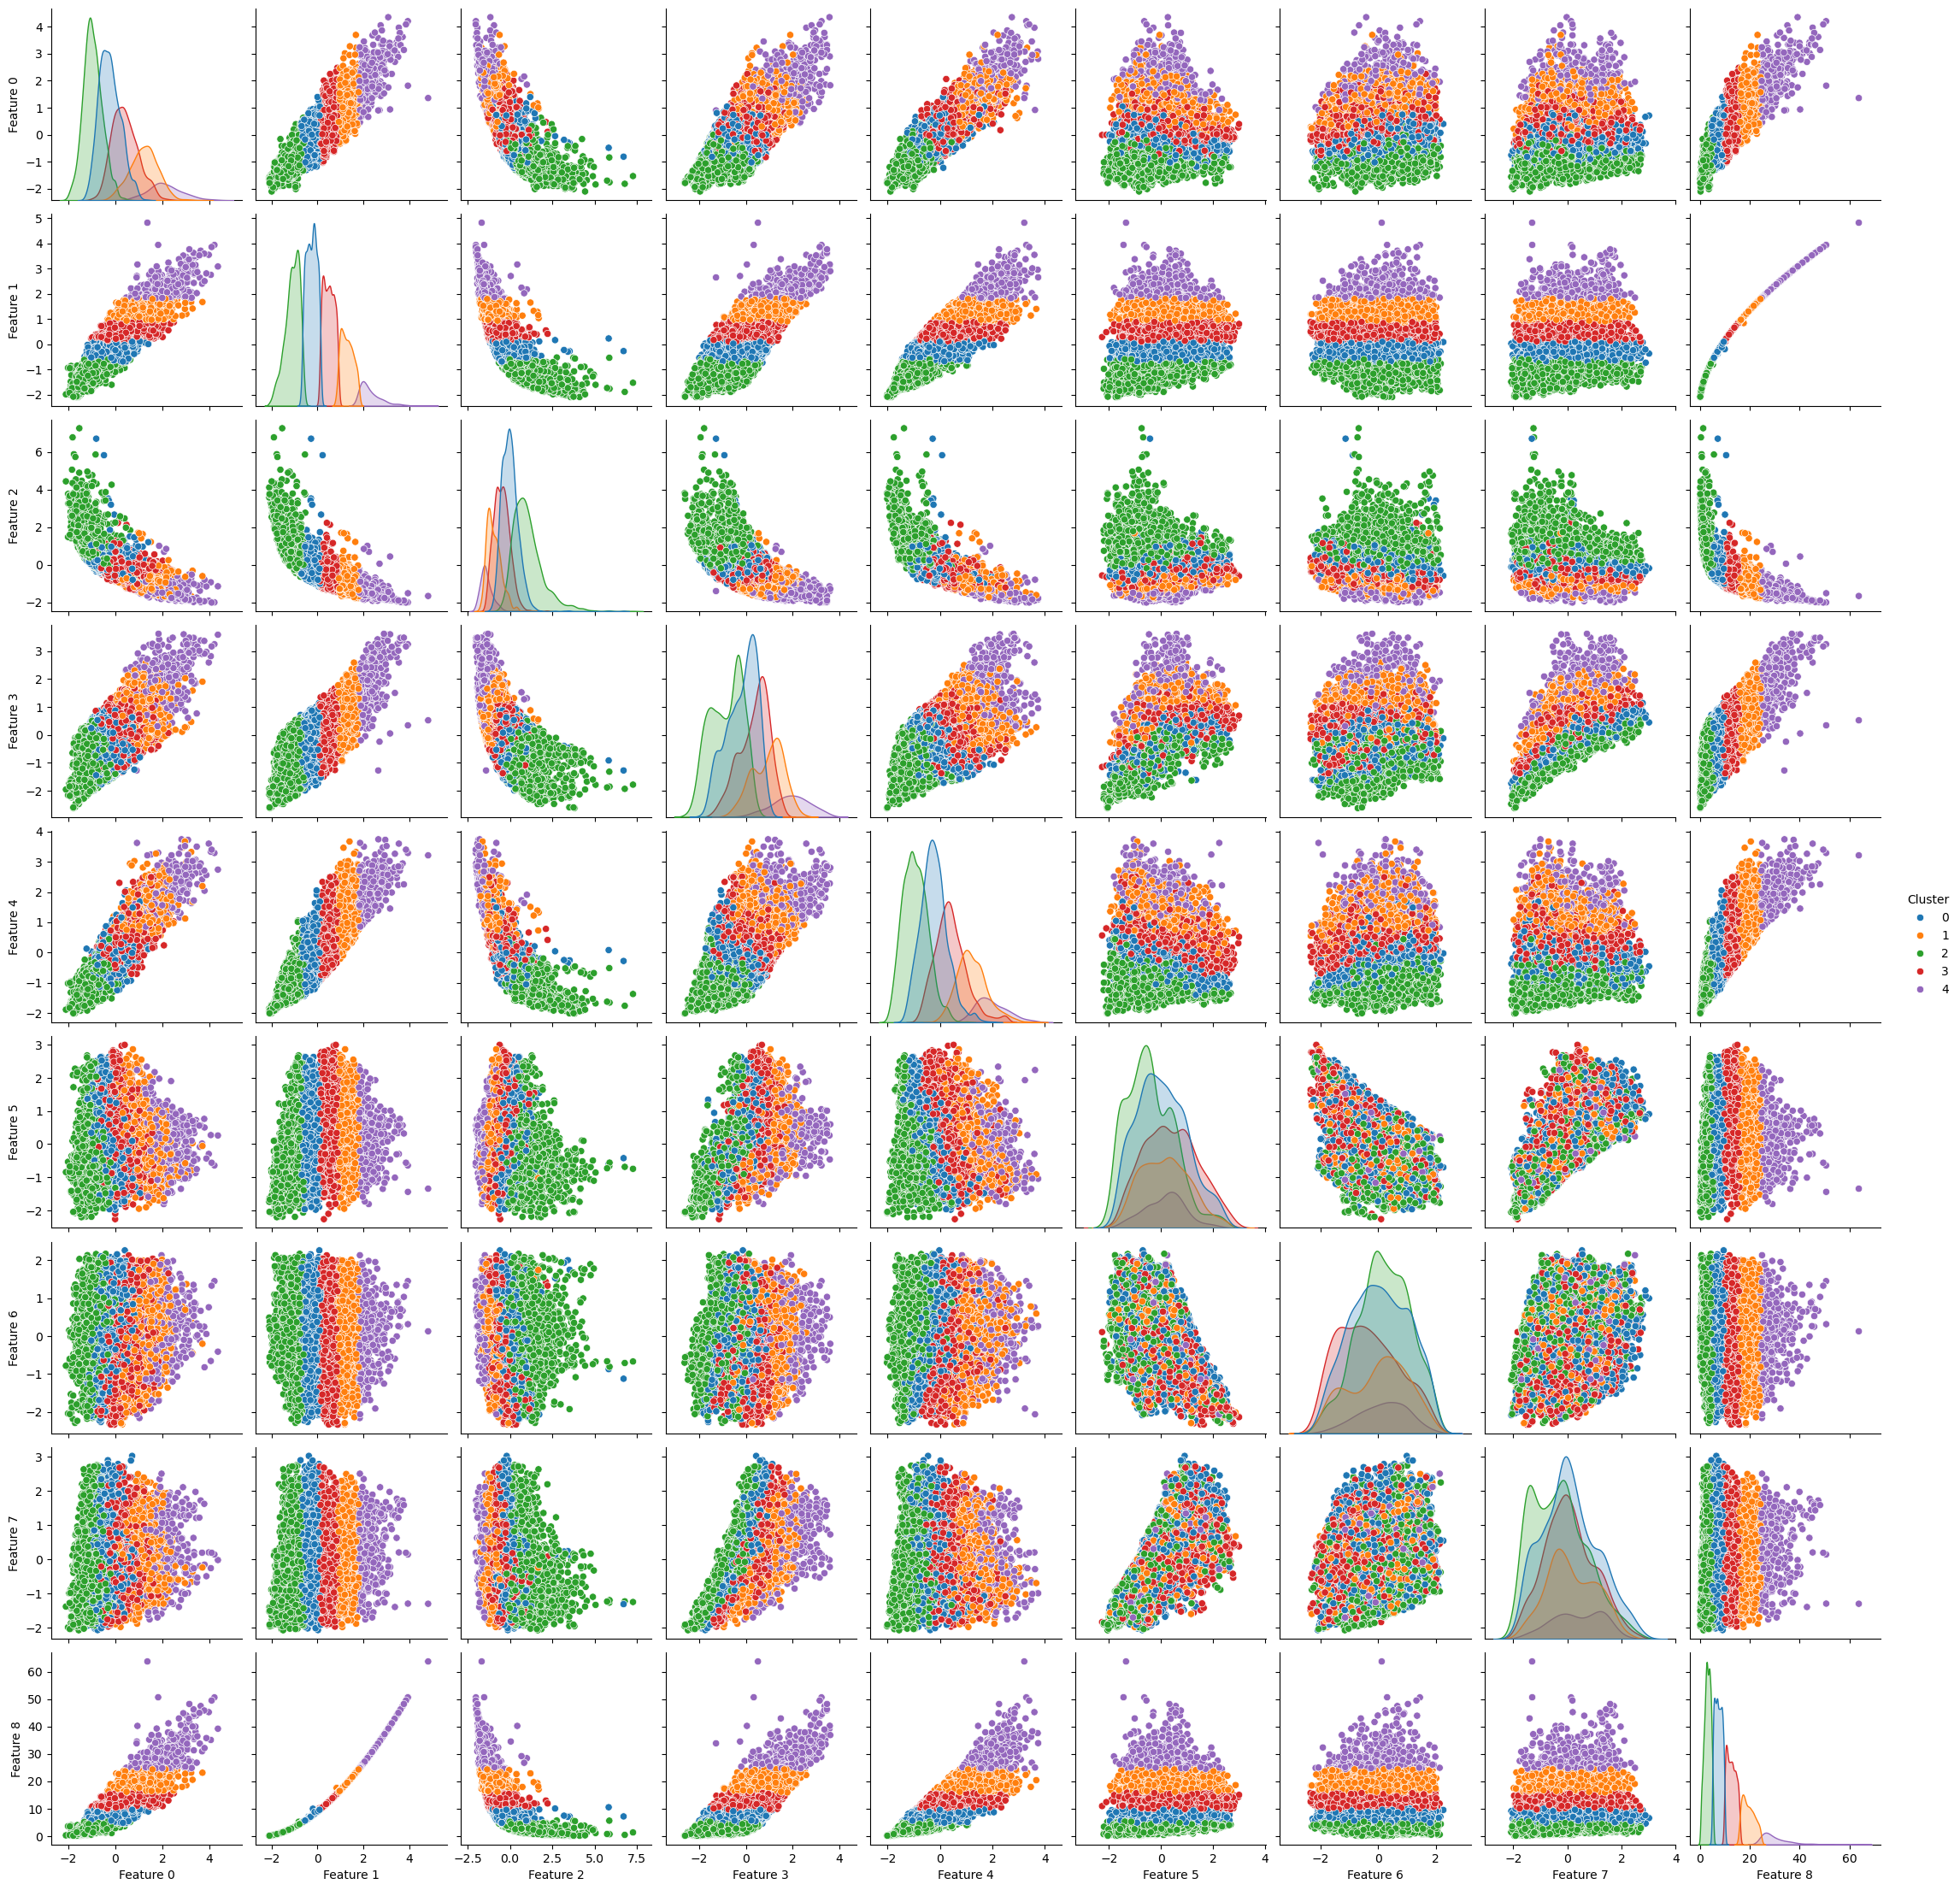

In [8]:
cluster_labels = np.argmax(u, axis=0)  

# Turn Xexp into a dataframe for plotting
df = pd.DataFrame(Xexp, columns=[f"Feature {i}" for i in range(Xexp.shape[1])])
df["Cluster"] = cluster_labels

# Pairplot with hue = cluster
sns.pairplot(df, vars=df.columns[:-1], hue="Cluster", palette="tab10", diag_kind="kde")
plt.show()

In [9]:
# Build ANFIS Model
ANFIS_model = TSK(n_inputs=Xtr.shape[1], n_rules=n_clusters, centers=centers[:,:-1], sigmas=sigmas[:,:-1])

# Convert to tensors
Xtr  = torch.tensor(Xtr, dtype=torch.float32)
ytr  = torch.tensor(ytr, dtype=torch.float32)
Xte  = torch.tensor(Xte, dtype=torch.float32)
yte  = torch.tensor(yte, dtype=torch.float32)

In [10]:
#Training with ANFIS
train_hybrid_anfis(ANFIS_model, Xtr, ytr.reshape(-1,1), max_iters=10, gd_epochs=20, lr=1e-3)

In [11]:
#Predictions
y_pred_ANFIS, _, _ = ANFIS_model(Xte)

# Compute MSE 
mse_ANFIS = mean_squared_error(yte.detach().numpy(), y_pred_ANFIS.detach().numpy())
print(f"MSE ANFIS: {mse_ANFIS}")

MSE ANFIS: 0.036439891904592514


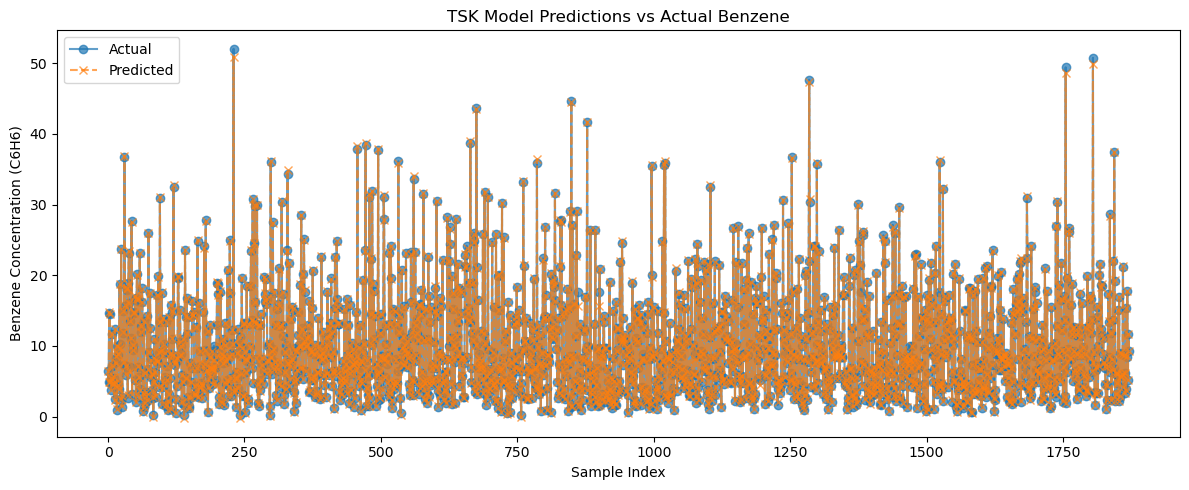

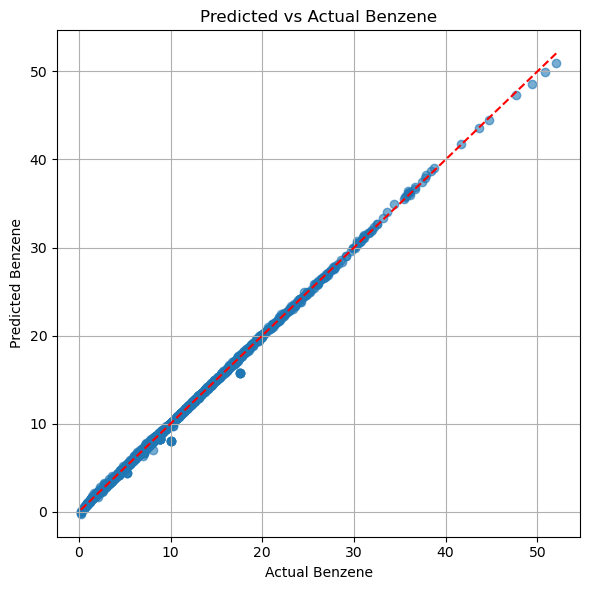

In [12]:
# Convert tensors to NumPy
y_true = yte.detach().numpy()
y_pred = y_pred_ANFIS.detach().numpy()

# Plot predictions vs actual
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="Actual", marker='o', linestyle='-', alpha=0.7)
plt.plot(y_pred, label="Predicted", marker='x', linestyle='--', alpha=0.7)
plt.title("TSK Model Predictions vs Actual Benzene")
plt.xlabel("Sample Index")
plt.ylabel("Benzene Concentration (C6H6)")
plt.legend()
plt.tight_layout()
plt.show()  # <-- newline separates this from the next figure

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Benzene")
plt.ylabel("Predicted Benzene")
plt.title("Predicted vs Actual Benzene")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Define paths
project_root = Path.cwd().parent  # goes from NoteBooks/ to Project/
trained_models_dir = project_root / "Trained_models"
trained_models_dir.mkdir(exist_ok=True)  # create folder if it doesn't exist
save_path = trained_models_dir / "Hybrid_ANFIS_Model.pth"

torch.save(ANFIS_model, save_path)